In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import r2_score
import pandas as pd

In [ ]:
train_data = np.load("data/train_data.npz")
target_scaler = joblib.load("data/target_scaler.pkl")
X_train = train_data['X_train']
X_test  = train_data['X_test']
y_train = train_data['y_train']
y_test  = train_data['y_test']

print('X_train shape:', X_train.shape)
print('y_train shape:', y_train.shape)

X_train shape: (672, 60, 5)
y_train shape: (672, 5)


In [4]:
import random
random.seed(37)
np.random.seed(37)
tf.random.set_seed(37)
#set random seeds for reproducibility

In [5]:
model = Sequential()
model.add(LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(32))
model.add(Dropout(0.2))
model.add(Dense(32, activation='gelu'))
model.add(Dense(y_train.shape[1], activation='softplus'))  # use softplus to ensure non-negative outputs
model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

c:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,557 (123.27 KB)

 Trainable params: 31,557 (123.27 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
from tensorflow.python.keras.callbacks import EarlyStopping
es = EarlyStopping(monitor='val_loss', patience=10, min_delta=1e-5, restore_best_weights=True)
#early stopping to prevent overfitting and optimize training time
history = model.fit(X_train, y_train, epochs=150, batch_size=32, validation_split=0.2, callbacks=[es])

Epoch 1/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - loss: 0.0555 - val_loss: 0.0206
Epoch 2/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0277 - val_loss: 0.0066
Epoch 3/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0116 - val_loss: 0.0049
Epoch 4/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0102 - val_loss: 0.0053
Epoch 5/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0076 - val_loss: 0.0034
Epoch 6/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0077 - val_loss: 0.0036
Epoch 7/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0068 - val_loss: 0.0044
Epoch 8/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0059 - val_loss: 0.0031
Epoch 9/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0059 - val_loss: 0.0029
Epoch 10/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0056 - val_loss: 0.0035
Epoch 11/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0055 - val_loss: 0.0031
Epoch 12/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step

In [ ]:
# Cell - Inverse transform
y_actual = target_scaler.inverse_transform(y_test)
y_pred   = target_scaler.inverse_transform(model.predict(X_test))

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step


In [ ]:
# Cell - Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mae  = mean_absolute_error(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
r2   = r2_score(y_actual, y_pred)

print(f'MAE:  {mae:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'R²:   {r2:.4f}')

MAE:       5470922.6807
RMSE:      14054422.7022
R²:        0.3925


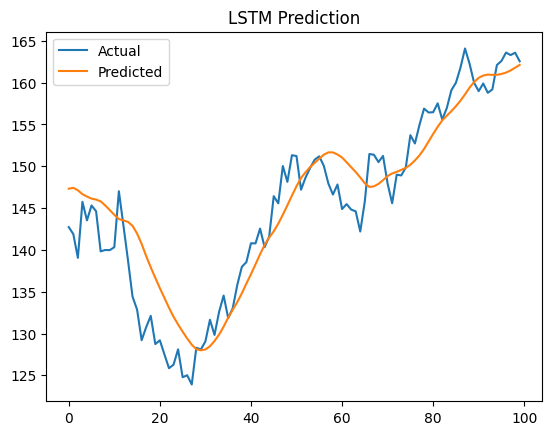

[142.71777001 141.8819673  139.04016788 145.73653203 143.52408428]
[147.30685 147.41255 147.11716 146.6581  146.36906]


In [9]:
plt.plot(y_actual[:100, 0], label='Actual')
plt.plot(y_pred[:100, 0], label='Predicted')
plt.legend()
plt.title('LSTM Prediction')
plt.show()
print(y_actual[:5, 0])
print(y_pred[:5, 0])

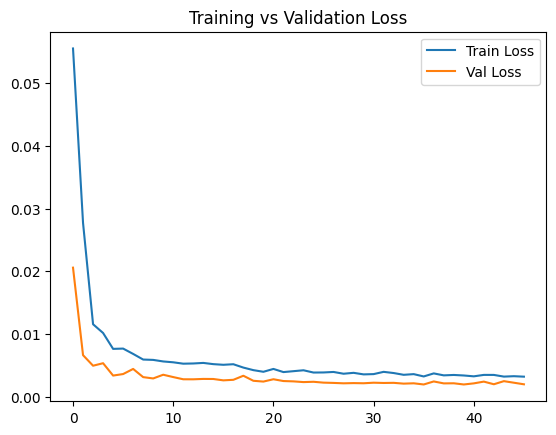

In [10]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()

In [11]:
model.save('artifact/lstm_model.h5')